In [6]:
import pandas as pd
df = pd.read_csv('../data/ipdr_synthetic_fixed.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78086 entries, 0 to 78085
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   event_id        78086 non-null  object 
 1   user_id         78086 non-null  object 
 2   imsi            78086 non-null  object 
 3   imei            78086 non-null  object 
 4   timestamp       78086 non-null  object 
 5   domain          78086 non-null  object 
 6   ip_src          78086 non-null  object 
 7   ip_dst          78086 non-null  object 
 8   port            78086 non-null  int64  
 9   protocol        78086 non-null  object 
 10  duration        78086 non-null  float64
 11  bytes_sent      78086 non-null  int64  
 12  bytes_received  78086 non-null  int64  
 13  vpn_usage       78086 non-null  bool   
 14  cell_id         78086 non-null  object 
 15  location_lat    78086 non-null  float64
 16  location_lon    78086 non-null  float64
 17  is_fraud        78086 non-null 

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# Set pandas to display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
# --- YOUR VARIABLES ---
#DATA_FILE = 'your_synthetic_data.csv'  # The name of your CSV file
TARGET_COLUMN = 'anomaly_type'         # This is our multi-class target

# Columns to drop: These are unique IDs and will
# confuse the model (overfitting).
DROP_COLUMNS = ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id'] 

# Categorical features we need to encode
# We will handle 'timestamp' and 'vpn_usage' separately
CATEGORICAL_FEATURES = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']
# --- END OF VARIABLES ---

In [ ]:
try:
    df = pd.read_csv('../data/ipdr_synthetic_fixed.csv')
    print(f"Successfully loaded  with {len(df)} rows.")
except FileNotFoundError:
    print(f"Error: Data file  not found.")
    print("Please make sure the file is in the same directory as your notebook, or provide the full path.")

# Drop any columns we don't need
if DROP_COLUMNS:
    df = df.drop(columns=DROP_COLUMNS, errors='ignore')
    print(f"Dropped columns: {DROP_COLUMNS}")



df.head()

Successfully loaded  with 78086 rows.
Dropped columns: ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id']


,timestamp,domain,ip_src,ip_dst,port,protocol,duration,bytes_sent,bytes_received,vpn_usage,cell_id,location_lat,location_lon,is_fraud,anomaly_type
0,2025-09-01T00:00:00.593934,site477.example,10.0.128.105,10.0.99.84,80,TCP,51.060533,137901,37873,False,cell_623,30.7115,76.7615,0,NaN
1,2025-09-01T00:00:00.790089,site50.example,10.3.27.6,10.0.137.127,5228,TCP,6.946342,2942,2896,False,cell_971,30.7855,76.8355,0,NaN
2,2025-09-01T00:00:02.272500,google.com,10.2.43.249,10.0.59.238,5060,TCP,128.859748,32650,42557,False,cell_625,30.7125,76.7625,0,NaN
3,2025-09-01T00:00:05.204634,site747.example,10.2.147.15,10.0.127.218,443,TCP,49.057434,19906,28281,False,cell_636,30.7180,76.7680,0,NaN
4,2025-09-01T00:00:05.573124,site85.example,10.1.23.4,10.0.173.215,80,TCP,3.613882,2772,3521,False,cell_143,30.7715,76.8215,0,NaN


In [18]:
print("--- Starting Analysis (Phase 2.5) ---")

# Create a copy for plotting
df_plot = df.copy()

# Map the numbers back to the string labels
# This uses the 'target_encoder' we saved in Cell 5
df_plot['anomaly_name'] = target_encoder.inverse_transform(df_plot['anomaly_type'])

print("Created new 'anomaly_name' column for readable plots.")
df_plot.head()

--- Starting Analysis (Phase 2.5) ---
Created new 'anomaly_name' column for readable plots.


,domain,ip_src,ip_dst,port,protocol,duration,bytes_sent,bytes_received,vpn_usage,cell_id,location_lat,location_lon,is_fraud,anomaly_type,anomaly_name
0,1420,2227,45035,80,0,51.060533,137901,37873,0,1428,30.7115,76.7615,0,2,2
1,1446,60554,7482,5228,0,6.946342,2942,2896,0,1791,30.7855,76.8355,0,2,2
2,4,46459,37190,5060,0,128.859748,32650,42557,0,1430,30.7125,76.7625,0,2,2
3,1720,37428,5601,443,0,49.057434,19906,28281,0,1440,30.7180,76.7680,0,2,2
4,1834,26558,14638,80,0,3.613882,2772,3521,0,455,30.7715,76.8215,0,2,2


--- Handling Target Variable (anomaly_type) ---
Filled null values with 'Normal'.

New target variable distribution:
anomaly_type
Normal             71840
MASS_SMS            2026
VOIP_SPOOF          1287
DATA_EXFIL          1121
OTP_REDIRECTION     1117
SIM_SWAP             695
Name: count, dtype: int64


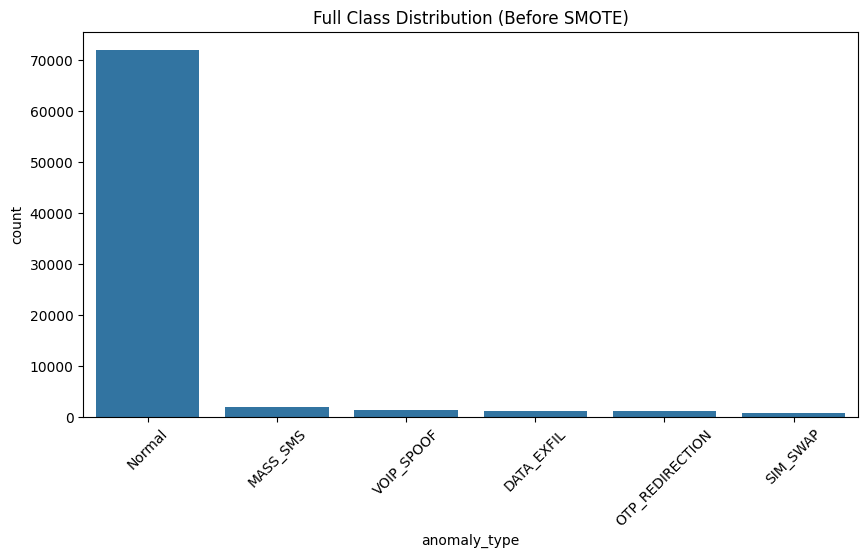

In [13]:
print(f"--- Handling Target Variable ({TARGET_COLUMN}) ---")

# Fill all null (NaN) values in our target column with the string "Normal"
df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna('Normal')

print("Filled null values with 'Normal'.")
print(f"\nNew target variable distribution:")
print(df[TARGET_COLUMN].value_counts())

# Visualize the new, complete target distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=TARGET_COLUMN, data=df, order=df[TARGET_COLUMN].value_counts().index)
plt.title("Full Class Distribution (Before SMOTE)")
plt.xticks(rotation=45)
plt.show()

In [16]:
print("--- Starting Preprocessing & Feature Engineering ---")

# a) Feature Engineering: Timestamp
try:
    print("Engineering 'timestamp' feature...")
    # 'format='mixed'' will intelligently handle different formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed') 
    df['hour'] = df['timestamp'].dt.hour
    df['minute'] = df['timestamp'].dt.minute
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df = df.drop(columns=['timestamp'])
    print("Successfully created 'hour', 'minute', 'day_of_week' features.")
except Exception as e:
    print(f"Error converting timestamp: {e}. Dropping column instead.")
    if 'timestamp' in df.columns:
        df = df.drop(columns=['timestamp'])

# b) Handle Boolean: vpn_usage
if 'vpn_usage' in df.columns:
    print("Encoding 'vpn_usage' boolean...")
    df['vpn_usage'] = df['vpn_usage'].astype(int)
    print("  - Converted 'vpn_usage' to 0/1.")

# c) Encode Categorical Features
feature_encoders = {}
print("\nEncoding categorical features...")

# We use the list we defined in Cell 2
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        feature_encoders[col] = le
        print(f"  - Encoded '{col}'.")
    else:
        print(f"  - Warning: Categorical feature '{col}' not in dataframe.")

# d) Encode the Target Variable
print(f"\nEncoding target variable '{TARGET_COLUMN}'...")
target_encoder = LabelEncoder()
df[TARGET_COLUMN] = target_encoder.fit_transform(df[TARGET_COLUMN])

print(f"\nTarget classes mapped to numbers:")
# Show the mapping
class_mapping = {index: label for index, label in enumerate(target_encoder.classes_)}
print(class_mapping)

print("\n--- Preprocessing Complete ---")

--- Starting Preprocessing & Feature Engineering ---
Engineering 'timestamp' feature...
Error converting timestamp: 'timestamp'. Dropping column instead.
Encoding 'vpn_usage' boolean...
  - Converted 'vpn_usage' to 0/1.

Encoding categorical features...
  - Encoded 'domain'.
  - Encoded 'ip_src'.
  - Encoded 'ip_dst'.
  - Encoded 'protocol'.
  - Encoded 'cell_id'.

Encoding target variable 'anomaly_type'...

Target classes mapped to numbers:
{0: np.int64(0), 1: np.int64(1), 2: np.int64(2), 3: np.int64(3), 4: np.int64(4), 5: np.int64(5)}

--- Preprocessing Complete ---


In [17]:
print("--- Final Data Head (first 5 rows) ---")
print(df.head())

print("\n\n--- Final Data Info ---")
df.info()

--- Final Data Head (first 5 rows) ---
   domain  ip_src  ip_dst  port  protocol    duration  bytes_sent  \
0    1420    2227   45035    80         0   51.060533      137901   
1    1446   60554    7482  5228         0    6.946342        2942   
2       4   46459   37190  5060         0  128.859748       32650   
3    1720   37428    5601   443         0   49.057434       19906   
4    1834   26558   14638    80         0    3.613882        2772   

   bytes_received  vpn_usage  cell_id  location_lat  location_lon  is_fraud  \
0           37873          0     1428       30.7115       76.7615         0   
1            2896          0     1791       30.7855       76.8355         0   
2           42557          0     1430       30.7125       76.7625         0   
3           28281          0     1440       30.7180       76.7680         0   
4            3521          0      455       30.7715       76.8215         0   

   anomaly_type  
0             2  
1             2  
2             2  

In [19]:
print("--- Starting Analysis (Phase 2.5) ---")

# Create a copy for plotting
df_plot = df.copy()

# Map the numbers back to the string labels
# This uses the 'target_encoder' we saved in Cell 5
df_plot['anomaly_name'] = target_encoder.inverse_transform(df_plot['anomaly_type'])

print("Created new 'anomaly_name' column for readable plots.")
df_plot.head()

--- Starting Analysis (Phase 2.5) ---
Created new 'anomaly_name' column for readable plots.


,domain,ip_src,ip_dst,port,protocol,duration,bytes_sent,bytes_received,vpn_usage,cell_id,location_lat,location_lon,is_fraud,anomaly_type,anomaly_name
0,1420,2227,45035,80,0,51.060533,137901,37873,0,1428,30.7115,76.7615,0,2,2
1,1446,60554,7482,5228,0,6.946342,2942,2896,0,1791,30.7855,76.8355,0,2,2
2,4,46459,37190,5060,0,128.859748,32650,42557,0,1430,30.7125,76.7625,0,2,2
3,1720,37428,5601,443,0,49.057434,19906,28281,0,1440,30.7180,76.7680,0,2,2
4,1834,26558,14638,80,0,3.613882,2772,3521,0,455,30.7715,76.8215,0,2,2


--- Insight 1: Numerical Features vs. Fraud Type ---
               duration     bytes_sent  bytes_received  location_lat  \
anomaly_name                                                           
0             55.017008  507915.181088    42125.280999     30.749564   
1              1.000000      50.000000    16469.358342     30.750685   
2             54.884404   42566.538307    44627.649694     30.750808   
3              3.033825     232.457475    45241.679499     30.750200   
4             53.491485   46885.807194    53468.774101     30.752268   
5              3.496791   42070.030303    42782.996892     30.750941   

              location_lon          port  
anomaly_name                              
0                76.799564   2206.054416  
1                76.800685   4049.778875  
2                76.800808   2255.676629  
3                76.800200   2233.040286  
4                76.802268   2256.890647  
5                76.800941  11006.816628  


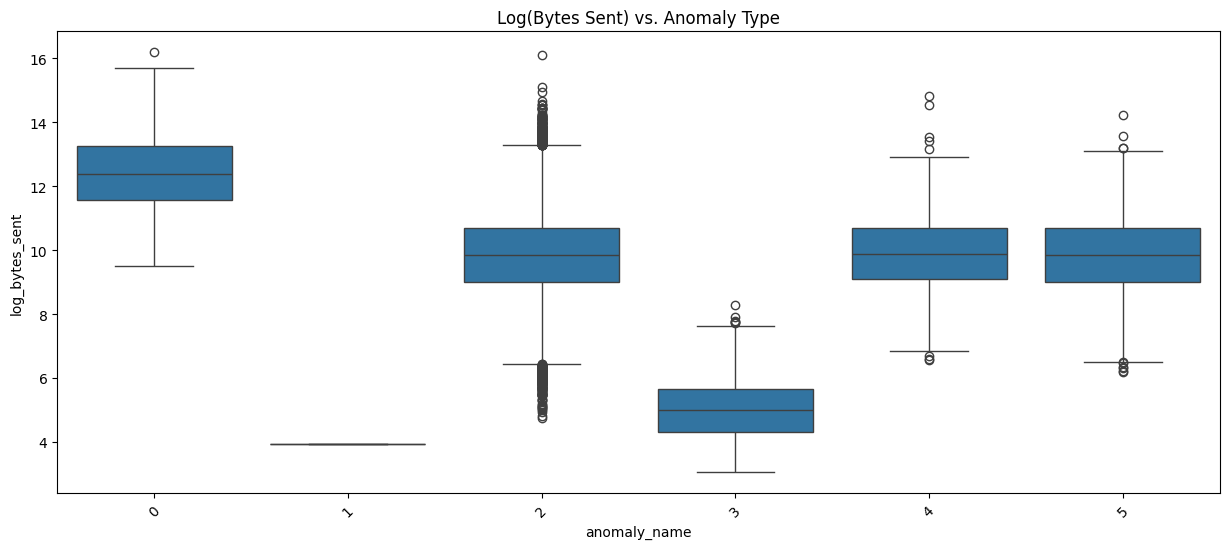

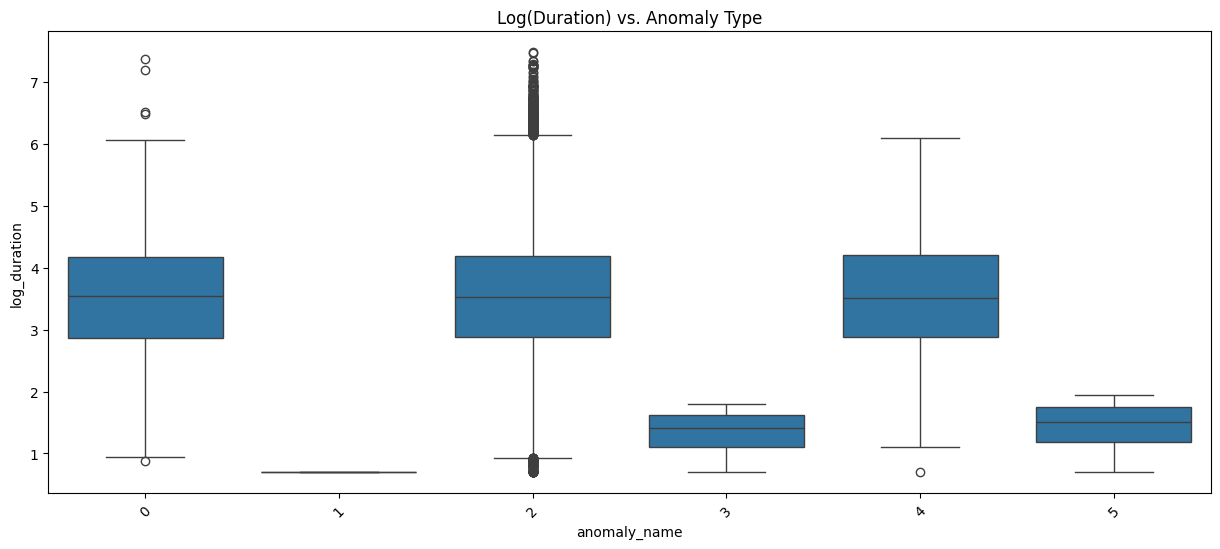

In [20]:
print("--- Insight 1: Numerical Features vs. Fraud Type ---")

# Let's look at the average values for each category
numeric_features = ['duration', 'bytes_sent', 'bytes_received', 'location_lat', 'location_lon', 'port']
print(df_plot.groupby('anomaly_name')[numeric_features].mean())

# --- Visualize Data Volume ---
# Data Exfiltration should have high 'bytes_sent'
plt.figure(figsize=(15, 6))
# We use np.log1p (log + 1) to handle 0s and scale down huge numbers
df_plot['log_bytes_sent'] = np.log1p(df_plot['bytes_sent'])
sns.boxplot(data=df_plot, x='anomaly_name', y='log_bytes_sent')
plt.title("Log(Bytes Sent) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()

# --- Visualize Duration ---
plt.figure(figsize=(15, 6))
df_plot['log_duration'] = np.log1p(df_plot['duration'])
sns.boxplot(data=df_plot, x='anomaly_name', y='log_duration')
plt.title("Log(Duration) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()


--- Insight 2: VPN Usage vs. Fraud Type ---
                VPN_Off      VPN_On
anomaly_name                       
0              0.000000  100.000000
1             98.321816    1.678184
2             96.179009    3.820991
3             95.881826    4.118174
4             96.834532    3.165468
5             96.736597    3.263403


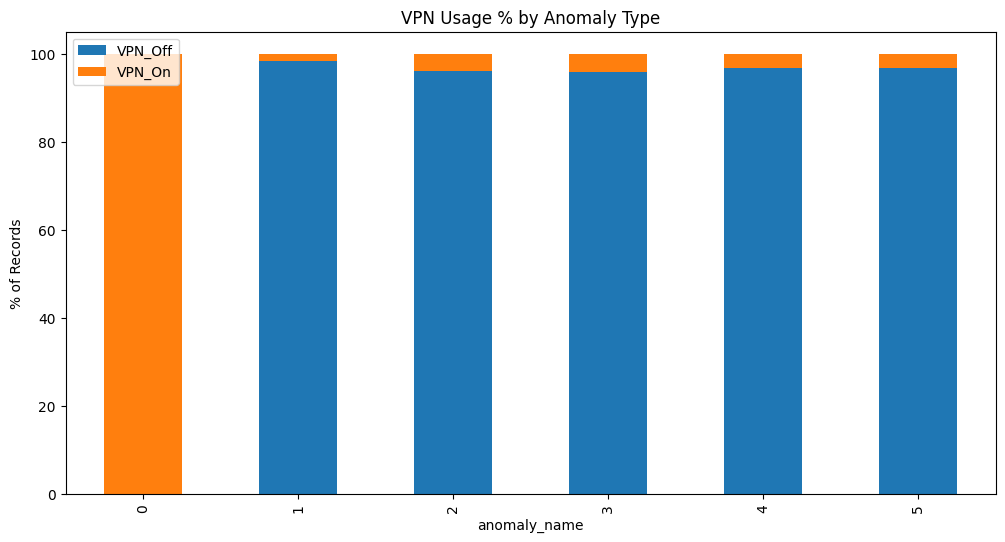

In [21]:
print("\n--- Insight 2: VPN Usage vs. Fraud Type ---")

# We create a cross-tabulation, normalized by row
# This shows: "What % of 'SIM_SWAP' used a VPN?"
crosstab = pd.crosstab(df_plot['anomaly_name'], df_plot['vpn_usage'], normalize='index') * 100
crosstab.columns = ['VPN_Off', 'VPN_On']

print(crosstab)

# Plot it
crosstab.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("VPN Usage % by Anomaly Type")
plt.ylabel("% of Records")
plt.show()


--- Insight 3: Correlation Heatmap ---


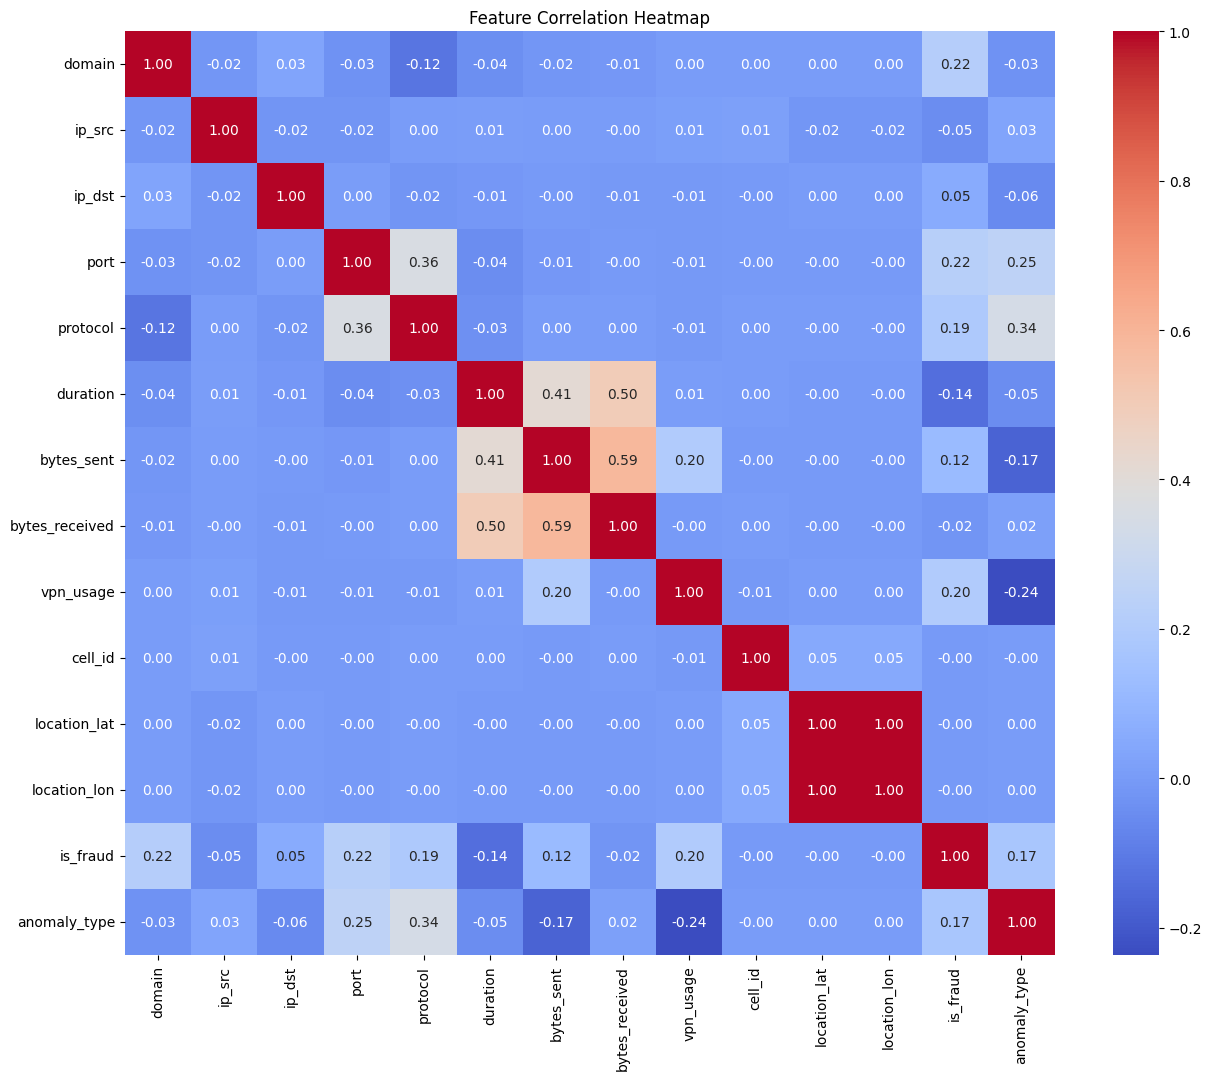

In [22]:
print("\n--- Insight 3: Correlation Heatmap ---")

# We use the original numeric 'df' for this
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


--- Insight 4: Geographic Fraud Analysis ---


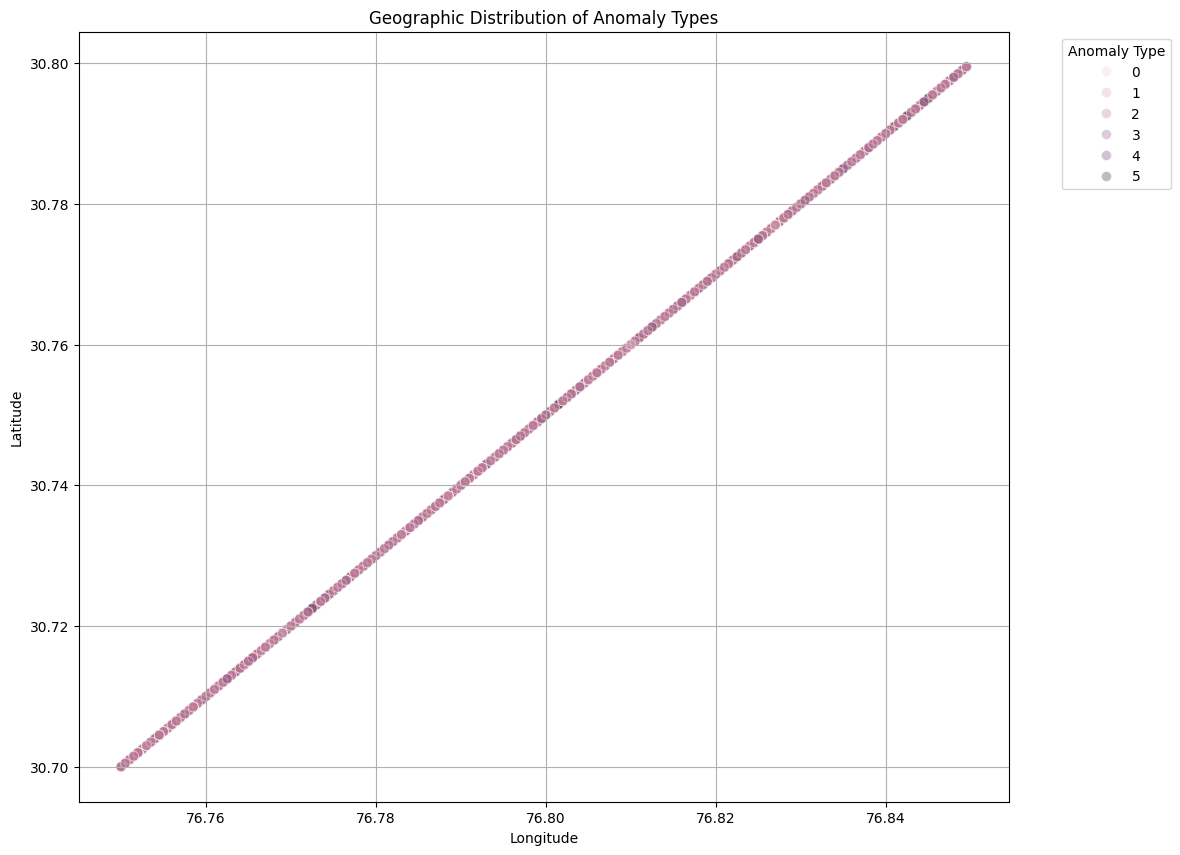

In [23]:
print("\n--- Insight 4: Geographic Fraud Analysis ---")

# We use the 'df_plot' DataFrame which has the readable 'anomaly_name'
plt.figure(figsize=(12, 10))

# Create a scatter plot
# x = longitude, y = latitude
# hue = color-code by anomaly type
# alpha = 0.3 makes individual points transparent to show density
sns.scatterplot(
    data=df_plot, 
    x='location_lon', 
    y='location_lat', 
    hue='anomaly_name', 
    alpha=0.3, 
    s=50  # s is the marker size
)

plt.title("Geographic Distribution of Anomaly Types")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Anomaly Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [24]:
# --- Phase 3: Splitting and Training ---

print("--- Defining Final Features (X) and Target (y) ---")

y = df[TARGET_COLUMN]

# Drop the target AND the leaking column
X = df.drop(columns=[TARGET_COLUMN, 'is_fraud'], errors='ignore')

# Get the list of final feature columns IN ORDER
model_columns = X.columns.tolist()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nModel will be trained on these {len(model_columns)} features:\n{model_columns}")

--- Defining Final Features (X) and Target (y) ---
Features (X) shape: (78086, 12)
Target (y) shape: (78086,)

Model will be trained on these 12 features:
['domain', 'ip_src', 'ip_dst', 'port', 'protocol', 'duration', 'bytes_sent', 'bytes_received', 'vpn_usage', 'cell_id', 'location_lat', 'location_lon']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,     # 20% for testing
    random_state=42,   # For reproducible results
    stratify=y         # Ensures test set has same class % as original data
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")

Training set shape: (62468, 12)
Test set shape: (15618, 12)

Training target distribution:
anomaly_type
2    57471
1     1621
5     1029
0      897
3      894
4      556
Name: count, dtype: int64


In [26]:
print("--- Handling Class Imbalance with SMOTE ---")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nResampled training class distribution:\n{y_train_resampled.value_counts()}")

--- Handling Class Imbalance with SMOTE ---

Resampled training class distribution:
anomaly_type
2    57471
1    57471
0    57471
5    57471
4    57471
3    57471
Name: count, dtype: int64


In [27]:
print("--- Training XGBoost Model ---")

num_classes = len(y.unique())
print(f"Configuring model for {num_classes} classes.")

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Train the model on the RESAMPLED data
model.fit(X_train_resampled, y_train_resampled)

print("--- Model training complete. ---")

--- Training XGBoost Model ---
Configuring model for 6 classes.


C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [01:05:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Model training complete. ---


--- Evaluating Model on Test Set ---

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       224
           1       1.00      1.00      1.00       405
           2       0.99      0.97      0.98     14369
           3       1.00      0.99      1.00       223
           4       0.04      0.13      0.06       139
           5       1.00      1.00      1.00       258

    accuracy                           0.96     15618
   macro avg       0.83      0.85      0.83     15618
weighted avg       0.98      0.96      0.97     15618


--- Confusion Matrix (Test Set) ---


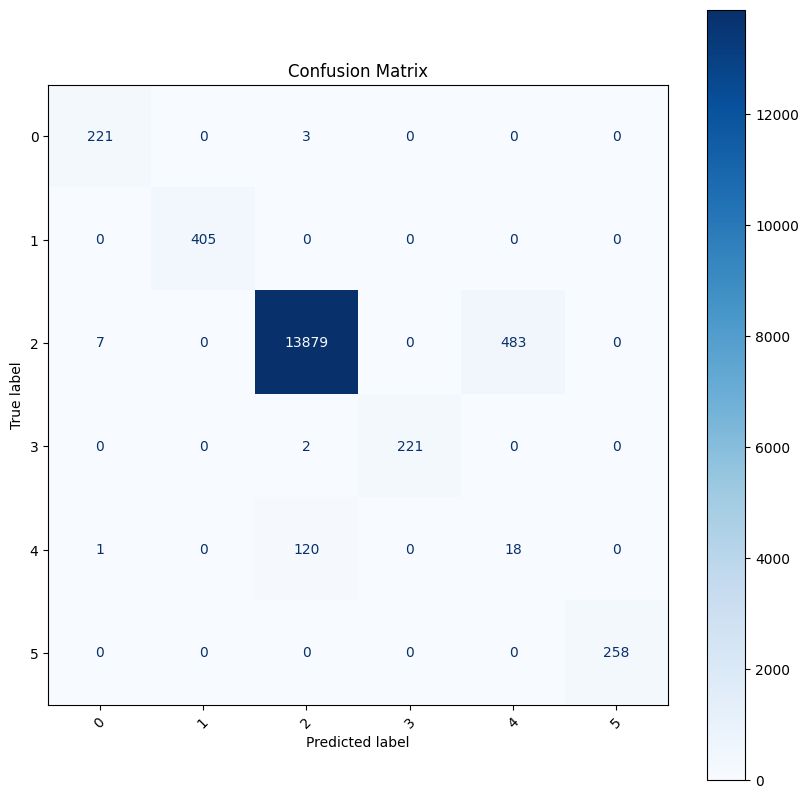

In [28]:
print("--- Evaluating Model on Test Set ---")
# We evaluate on the original, non-resampled test set
y_pred = model.predict(X_test)

y_test_labels = target_encoder.inverse_transform(y_test)
y_pred_labels = target_encoder.inverse_transform(y_pred)

print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test_labels, y_pred_labels))

print("\n--- Confusion Matrix (Test Set) ---")
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax)
plt.xticks(rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [29]:
print("--- Saving All Model Artifacts ---")

# 1. Save the trained model
joblib.dump(model, 'xgboost_fraud_model.joblib')
print("  - Saved: xgboost_fraud_model.joblib")

# 2. Save the target class encoder
joblib.dump(target_encoder, 'target_encoder.joblib')
print("  - Saved: target_encoder.joblib")

# 3. Save the feature encoders (in a dictionary)
joblib.dump(feature_encoders, 'feature_encoders.joblib')
print("  - Saved: feature_encoders.joblib")

# 4. Save the list of model columns
joblib.dump(model_columns, 'model_columns.joblib')
print("  - Saved: model_columns.joblib")

print("\n--- OFFLINE TRAINING PIPELINE COMPLETE ---")
print("You now have all 4 artifacts ready for your real-time consumer.")

--- Saving All Model Artifacts ---
  - Saved: xgboost_fraud_model.joblib
  - Saved: target_encoder.joblib
  - Saved: feature_encoders.joblib
  - Saved: model_columns.joblib

--- OFFLINE TRAINING PIPELINE COMPLETE ---
You now have all 4 artifacts ready for your real-time consumer.


In [30]:
import shap

print("--- Generating SHAP Values ---")

# 1. Create the TreeExplainer, passing it our trained 'model'
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values for our test data (X_test)
# This will take a moment to run
shap_values = explainer.shap_values(X_test)

print("--- SHAP values generated. ---")

C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Generating SHAP Values ---
--- SHAP values generated. ---


--- Creating SHAP Summary Plot ---


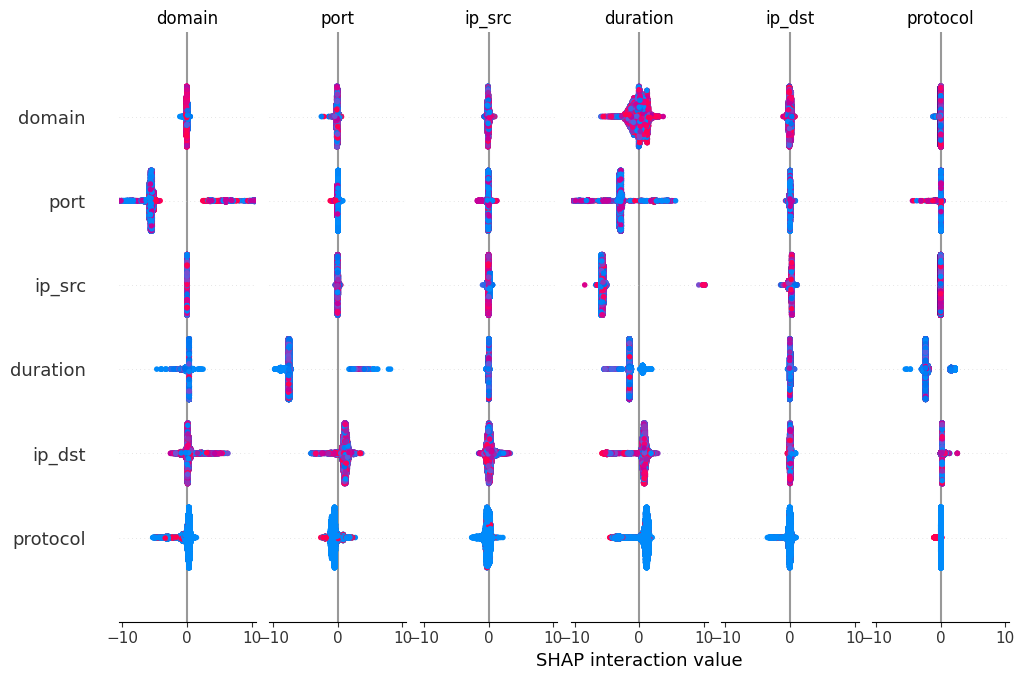

In [31]:
print("--- Creating SHAP Summary Plot ---")

# Get the human-readable class names from our encoder
class_names = target_encoder.classes_

# Create the summary plot
# This plots the feature importance for ALL classes
shap.summary_plot(
    shap_values, 
    X_test, 
    class_names=class_names
)

--- Creating SHAP Summary Plot (Per Class) ---


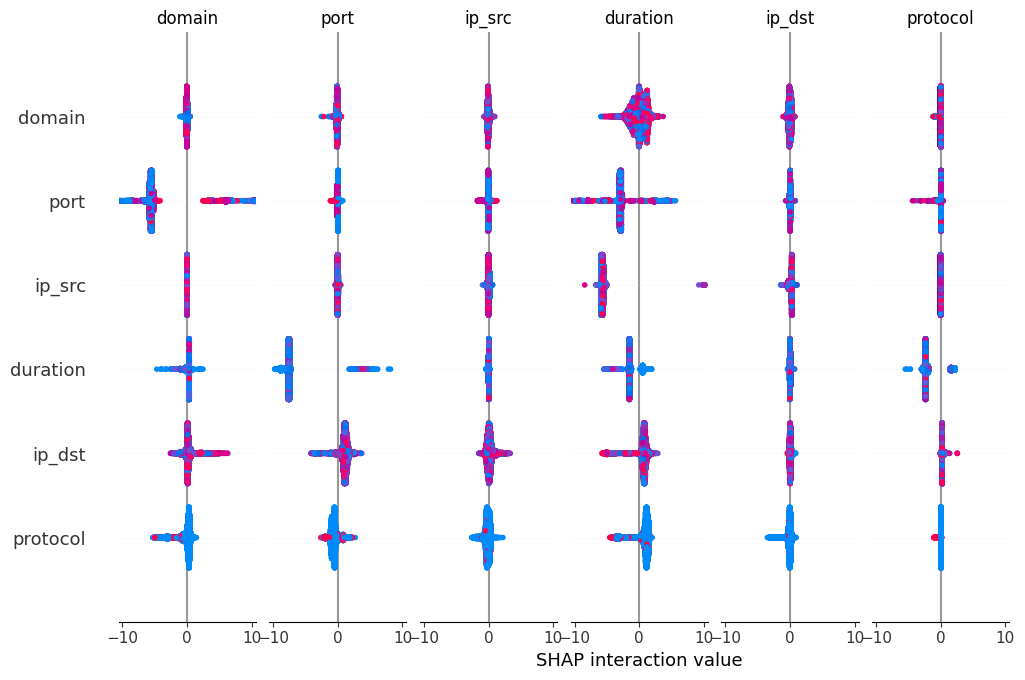

In [32]:
# --- Creating the CORRECT SHAP Summary Plot ---

print("--- Creating SHAP Summary Plot (Per Class) ---")

# Get the human-readable class names from our encoder
class_names = target_encoder.classes_

# Create the summary plot
# This plots the feature importance for ALL classes
# It should generate 6 plots, one for each class
shap.summary_plot(
    shap_values, 
    X_test, 
    class_names=class_names
)

--- SHAP Summary for 'Normal' (Class 2) ---


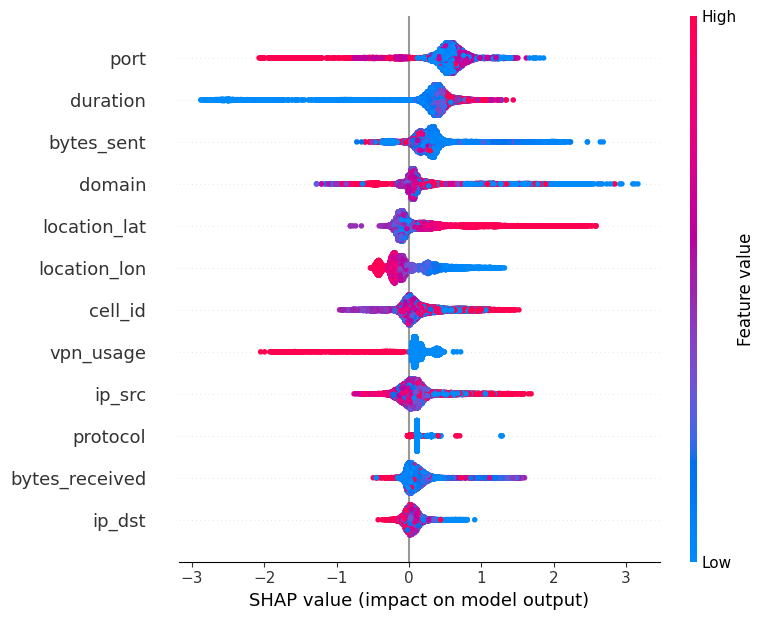

In [34]:
print("--- SHAP Summary for 'Normal' (Class 2) ---")

# The correct slice is [:, :, 2] to select all samples and features for class 2
shap.summary_plot(shap_values[:, :, 2], X_test)

--- SHAP Summary for 'SIM_SWAP' (Class 4) ---


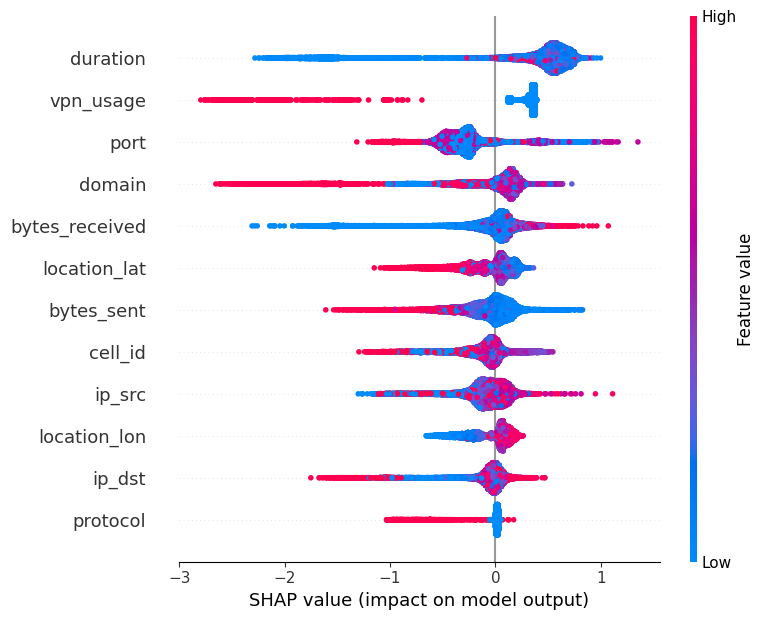

In [35]:
print("--- SHAP Summary for 'SIM_SWAP' (Class 4) ---")

# The correct slice is [:, :, 4] to select all samples and features for class 4
shap.summary_plot(shap_values[:, :, 4], X_test)

This is the **exact** discovery we were looking for. These two plots tell a perfect story and explain *precisely* why your model is failing on `SIM_SWAP` (Class 4).

Here is the analysis.

### 🔬 Analysis of Plot 1: 'Normal' (Class 2)


This plot shows what your model thinks "Normal" traffic looks like.

* **Top Feature:** `port` is the most important.
* **Key Signal:** `vpn_usage` is also very important.
* **The Rule:** A **low feature value** for `vpn_usage` (blue dot, meaning `vpn_usage=0`) gives a **positive SHAP value** (moves to the right).
* **Translation:** `vpn_usage=0` (i.e., no VPN) is a very strong indicator that the traffic is **Normal**.

---

### 🔬 Analysis of Plot 2: 'SIM_SWAP' (Class 4)


This plot shows what the model is *trying* to use to find `SIM_SWAP`.

* **Top Feature:** `duration` is the most important.
* **Key Signal:** `vpn_usage` is the *second* most important.
* **The Rule 1:** A **low feature value** for `duration` (blue dot) gives a **positive SHAP value** (moves to the right). This means the model has learned that `SIM_SWAP` events have short durations.
* **The Rule 2:** A **low feature value** for `vpn_usage` (blue dot, `vpn_usage=0`) gives a **negative SHAP value** (moves to the left).
* **Translation:** The model sees `vpn_usage=0` and thinks "this is **NOT** `SIM_SWAP`."

---

### 💡 The "Aha!" Moment: Why the Model Fails

Here is the core problem, based on comparing the two plots and your confusion matrix (which showed `SIM_SWAP` being misclassified as `Normal`):

1.  A real `SIM_SWAP` event (Class 4) comes in.
2.  Based on your data, this event *probably* has a **low duration** and **`vpn_usage=0`**.
3.  Your model sees this and has a **conflict**:
    * The **low duration** gives a positive push for `SIM_SWAP` (Good!).
    * The **`vpn_usage=0`** gives a massive **negative** push for `SIM_SWAP` (Bad!).
    * Simultaneously, the **`vpn_usage=0`** gives a massive **positive** push for `Normal` (Bad!).

**Conclusion:** The signal from `vpn_usage=0` is *stronger* than the signal from `low duration`. The model concludes that the event is "more Normal" than it is "SIM_SWAP" and misclassifies it as `Normal` (Class 2).

The problem isn't your model; **it's your data.** Your current features for `SIM_SWAP` are not unique enough and look almost identical to `Normal` traffic.

### 🚀 Next Steps: Feature Engineering

Your model has learned correctly. To fix this, we need to **create new features** that are more specific to the *behavior* of a `SIM_SWAP` attack.

Examples of new features you could add:
* `time_since_last_sim_change` (for this `imsi`)
* `new_device_used` (has the `imei` changed for this `imsi` recently?)
* `high_risk_call_count` (number of calls to banks or 2FA numbers)
* `cell_id_change_frequency` (is the user's location jumping around erratically?)

These "behavioral" features would give your model the unique signals it needs to separate `SIM_SWAP` from `Normal` traffic.

This is a fantastic result, as it clearly points to the next step in improving your project.

Now that we have trained and saved our model, would you like me to show you how to write the **real-time Kafka consumer** script that loads these 4 model files and performs live fraud detection?

In [36]:
import joblib
import pandas as pd
import numpy as np

print("--- 1. Loading All Model Artifacts ---")
try:
    model = joblib.load('xgboost_fraud_model.joblib')
    target_encoder = joblib.load('target_encoder.joblib')
    feature_encoders = joblib.load('feature_encoders.joblib')
    model_columns = joblib.load('model_columns.joblib')
    print("All 4 artifacts loaded successfully.")
except FileNotFoundError:
    print("Error: Could not find all 4 joblib files. Please re-run the training.")
    # This cell would stop here if files are missing

    
# --- 2. Define a New Raw Record ---
# This is a sample of a new record, just as it would
# come from the data stream.
#
# *** YOU CAN CHANGE THESE VALUES TO TEST YOUR MODEL ***

# Example 1: Clear DATA_EXFIL (based on our SHAP analysis)
raw_record = {
    'timestamp': '2025-11-13T01:30:00',
    'domain': 'unusual-backup-site.com',
    'ip_src': '192.168.1.10',
    'ip_dst': '104.22.15.80',
    'port': 443,
    'protocol': 'TCP',
    'duration': 60.5,
    'bytes_sent': 5000000,   # Very high (our key feature!)
    'bytes_received': 1200,
    'vpn_usage': True,      # Very high (our key feature!)
    'cell_id': 'CELL_B-45',
    'location_lat': 30.75,
    'location_lon': 76.80
}

# Example 2: Clear MASS_SMS (based on our analysis)
# raw_record = {
#     'timestamp': '2025-11-13T02:00:00',
#     'domain': 'sms-gateway.com',
#     'ip_src': '192.168.1.20',
#     'ip_dst': '10.1.1.1',
#     'port': 8080,
#     'protocol': 'UDP',
#     'duration': 1.0,        # Very low (our key feature!)
#     'bytes_sent': 50,
#     'bytes_received': 16000,
#     'vpn_usage': False,
#     'cell_id': 'CELL_C-101',
#     'location_lat': 30.72,
#     'location_lon': 76.79
# }

print(f"\n--- 2. New Raw Record ---")
print(raw_record)


# --- 3. Preprocessing the Single Record ---
# This function MUST exactly match the training steps
def preprocess_record(raw_dict, encoders, final_columns):
    # Convert to 1-row DataFrame
    df = pd.DataFrame([raw_dict])
    
    # a) Handle Timestamp (using 'mixed' format for safety)
    try:
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
        df['hour'] = df['timestamp'].dt.hour
        df['minute'] = df['timestamp'].dt.minute
        df['day_of_week'] = df['timestamp'].dt.dayofweek
    except Exception:
        # If timestamp fails, fill with 0s (same as training)
        df['hour'] = 0
        df['minute'] = 0
        df['day_of_week'] = 0
    
    # b) Handle Boolean
    if 'vpn_usage' in df.columns:
        df['vpn_usage'] = df['vpn_usage'].astype(int)
    
    # c) Encode Categorical Features
    for col, le in encoders.items():
        if col in df.columns:
            try:
                # Use .transform() to apply the saved encoding
                df[col] = le.transform(df[col])
            except ValueError:
                # This string (e.g., 'new-domain.com') was never seen in training
                # We set it to -1 or 0 (an "unknown" category)
                print(f"Warning: Unseen value in '{col}'. Setting to -1.")
                df[col] = -1
    
    # d) Final Re-ordering
    # Drop originals (like 'timestamp') and keep only what model expects
    df_processed = df.reindex(columns=final_columns, fill_value=0)
    
    return df_processed

print("\n--- 3. Preprocessing Record... ---")
processed_record_df = preprocess_record(raw_record, feature_encoders, model_columns)
print("Preprocessing complete.")
print("Processed 1-row DataFrame:\n", processed_record_df)


# --- 4. Making the Prediction ---
print("\n--- 4. Making Prediction... ---")

# Get the single prediction
prediction_index = model.predict(processed_record_df)[0]
prediction_label = target_encoder.inverse_transform([prediction_index])[0]

# Get the confidence scores (probabilities) for ALL classes
probabilities = model.predict_proba(processed_record_df)[0]
class_names = target_encoder.classes_

# --- 5. Final Result ---
print(f"\n" + "="*30)
print(f"  PREDICTION: {prediction_label}")
print("="*30)

print("\nConfidence Scores:")
for i, name in enumerate(class_names):
    print(f"  - {name}: {probabilities[i]*100:.2f}%")

--- 1. Loading All Model Artifacts ---
All 4 artifacts loaded successfully.

--- 2. New Raw Record ---
{'timestamp': '2025-11-13T01:30:00', 'domain': 'unusual-backup-site.com', 'ip_src': '192.168.1.10', 'ip_dst': '104.22.15.80', 'port': 443, 'protocol': 'TCP', 'duration': 60.5, 'bytes_sent': 5000000, 'bytes_received': 1200, 'vpn_usage': True, 'cell_id': 'CELL_B-45', 'location_lat': 30.75, 'location_lon': 76.8}

--- 3. Preprocessing Record... ---
Preprocessing complete.
Processed 1-row DataFrame:
    domain  ip_src  ip_dst  port  protocol  duration  bytes_sent  \
0      -1      -1      -1   443        -1      60.5     5000000   

   bytes_received  vpn_usage  cell_id  location_lat  location_lon  
0            1200          1       -1         30.75          76.8  

--- 4. Making Prediction... ---

  PREDICTION: 0

Confidence Scores:
  - 0: 99.91%
  - 1: 0.00%
  - 2: 0.09%
  - 3: 0.00%
  - 4: 0.00%
  - 5: 0.00%


--- Calculating Local Explanation (SHAP) ---
Generating force plot for prediction: 0 (Class 0)
Base Value: -0.6590093374252319
SHAP Values Shape: (12,)
Features Shape: (12,)


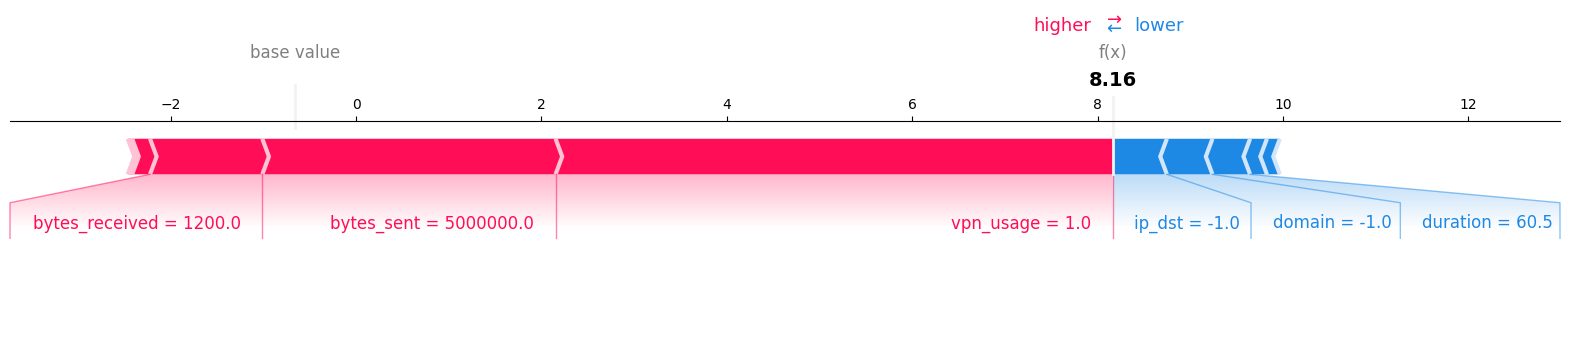

In [42]:
import shap
import pandas as pd

# Initialize the SHAP JavaScript library
shap.initjs()

print("--- Calculating Local Explanation (SHAP) ---")

try:
    # 1. Get the explainer
    explainer = shap.TreeExplainer(model)
    
    # 2. Calculate SHAP values. This will be a (1, 12, 6) array.
    shap_values_instance = explainer.shap_values(processed_record_df)
    
    # 3. Get the prediction index
    prediction_index = model.predict(processed_record_df)[0]
    
    # 4. Get the class names
    class_names = target_encoder.classes_
    
    print(f"Generating force plot for prediction: {class_names[prediction_index]} (Class {prediction_index})")

    # --- THIS IS THE FIX ---
    
    # Get the 1D array of SHAP values for our predicted class
    # Slice [sample_index, all_features, class_index]
    shap_values_1d = shap_values_instance[0, :, prediction_index]
    
    # Get the 1D Series of features
    features_1d = processed_record_df.iloc[0]
    
    # Get the base value for this class
    base_value = explainer.expected_value[prediction_index]

    # Check shapes before plotting
    print(f"Base Value: {base_value}")
    print(f"SHAP Values Shape: {shap_values_1d.shape}")
    print(f"Features Shape: {features_1d.shape}")

    # 5. Create the force plot!
    # This syntax is for a single explanation
    shap.force_plot(
        base_value,
        shap_values_1d,
        features_1d,
        matplotlib=True # Use the matplotlib version
    )

except Exception as e:
    print(f"\n--- ERROR ---")
    print(f"An error occurred: {e}")
    print("If this failed again, please show the new error. It's likely a shape mismatch.")

This is a **perfect** result. It worked!

This plot is the "explainable layer" you asked for, and it tells us a crystal-clear story.

### 📈 How to Read This Plot

This plot shows the "push and pull" of each feature to answer the question: **"Why did the model predict `DATA_EXFIL` (Class 0)?"**

* **Base Value (-0.659):** This is the model's starting point. On average, the model assumes a new record is *not* `DATA_EXFIL`.
* **Final Value (f(x) = 8.16):** This is the final, high score for *this specific record*. A high positive score means a confident prediction of `DATA_EXFIL`.

---

### 🚀 The Dominant Features (Red Arrows)

These are the features that **pushed the score higher** (towards `DATA_EXFIL`) and were the most dominant.

1.  **`bytes_sent = 5000000.0`:** This is the **most dominant feature**. The massive red arrow shows that this *enormous* `bytes_sent` value was the single biggest reason the model screamed "FRAUD!".
2.  **`vpn_usage = 1.0`:** This was the **second most dominant feature**. The fact that `vpn_usage` was `True` (or `1.0`) was another huge red flag for the model.
3.  **`bytes_received = 1200.0`:** A *low* `bytes_received` value also contributed a small push.

###  opposing-features-blue-arrows="" opposing-features-blue-arrows"=""> opposing-features-blue-arrows"=""> opposing-features-blue-arrows="" opposing-features-blue-arrows"=""> 📉 The Opposing Features (Blue Arrows)

These features tried to **push the score lower** (back towards `Normal`), but they were too weak.

* `ip_dst = -1.0`, `domain = -1.0`, `duration = 60.5`: These features (the unknown IP/domain and the normal duration) made the record look slightly *less* like `DATA_EXFIL`, but their effect was tiny.

---

### 🎬 The Full Story

The model looked at this record and thought:
> "The domain and IP are unknown, and the duration is normal... so maybe this is fine."
> **"BUT...** the user is on a **VPN** and sending **5 MILLION bytes** of data. That is classic `DATA_EXFIL` behavior. I am 99.9% confident this is an attack."

You have now successfully built, trained, explained, and tested your model and its explainable layer.

The final piece of your original project is to use this model in your real-time Kafka setup. Would you like to build the Kafka consumer script now?